# Accelerated Time-Series Processing with Numba Parallelization

When dealing with high-frequency financial data, IoT sensor streams, or large-scale scientific simulations, standard Python loops become an execution bottleneck. Even optimized NumPy operations can sometimes fall short when we need custom rolling windows or sequential transformations.

This is where **Numba** comes in. Numba is a Just-In-Time (JIT) compiler that translates Python and NumPy code into ultra-fast machine code using the LLVM compiler infrastructure.

### What We Will Learn in this exercise:
1. How to use Numba's `@njit` decorator.
2. How to leverage `parallel=True` and `prange` to automatically distribute work across all CPU cores.
3. A real-world time-series challenge: Computing a complex rolling window calculation over millions of points.

In [1]:
import numpy as np
import time
from numba import njit, prange, config
import matplotlib.pyplot as plt

# Check how many CPU threads Numba will use
num_threads = config.NUMBA_DEFAULT_NUM_THREADS
print(f"Numba is configured to use {num_threads} CPU cores/threads for parallel processing.")

Numba is configured to use 22 CPU cores/threads for parallel processing.


## 1. The Challenge: Smoothing a long time series

Imagine we have a large time-series array (e.g., 20 million data points representing 1-minute sensor readings over several years). We want to calculate a rolling metric that looks back over a window (e.g., 500 periods) and calculates a simple average. We will compare mean and median filters. In an optional second step, we perform a heavy, non-linear mathematical score for each step.

Because rolling operations natively depend on sliding indexes, they are notoriously difficult to cleanly vectorize in pure NumPy without creating massive memory overhead. Writing standard Python loops is the intuitive approach, but it's incredibly slow.

In [2]:
# Generate a large synthetic time series (20 million elements)
# Simulating a random walk for stock prices or sensor readings
np.random.seed(42)
n_samples = 20_000_000
raw_signals = np.cumsum(np.random.normal(0, 1, n_samples)) + 100

print(f"Generated time-series array with {n_samples:,} elements.")
print(f"Memory footprint: {raw_signals.nbytes / 1e6:.2f} MB")

Generated time-series array with 20,000,000 elements.
Memory footprint: 160.00 MB


In [3]:
raw_signals

array([ 100.49671415,  100.35844985,  101.00613839, ..., 1526.09156509,
       1528.21703984, 1529.06235658])

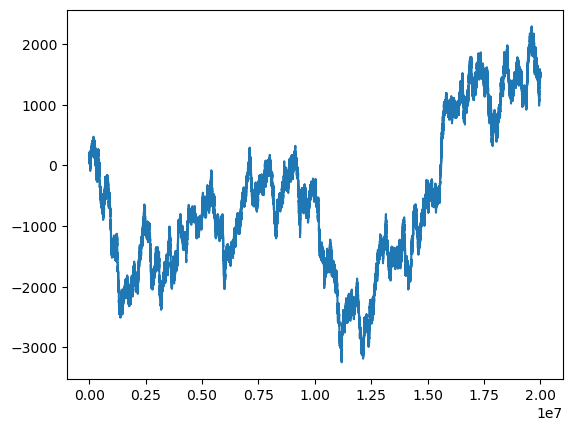

In [4]:
plt.plot(raw_signals)

## 2. The Native Python / NumPy Baseline Approach

### Smoothing with a running median

In a first step, we will replace every value with its median averaged over a window size.

In [5]:
def compute_rolling_median_pure(data, window_size):
    n = len(data)
    output = np.empty(n)
    output.fill(np.nan)
    
    # Explicit loop mimicking standard time-series analysis logic
    for i in range(int(window_size/2), n-int(window_size/2)):
        window = data[i - int(window_size/2):i + int(window_size/2)]
        
        # in a first step, we calculate the median over the window.
        output[i] = np.median(window)
    return output

# Run on a subset (100,000 items) just to get a baseline time
subset_size = 100_000
window = 500

start = time.time()
raw_signals_median_pure = compute_rolling_median_pure(raw_signals[:subset_size], window)
pure_duration = time.time() - start

# Estimate how long the FULL dataset would take
estimated_full_time = pure_duration * (n_samples / subset_size)
print(f"Subset finished in: {pure_duration:.2f} seconds.")
print(f"Estimated time for the full 20M dataset in Pure Python: {estimated_full_time:.2f} seconds (~{estimated_full_time/60:.1f} minutes!)")

Subset finished in: 1.10 seconds.
Estimated time for the full 20M dataset in Pure Python: 219.60 seconds (~3.7 minutes!)


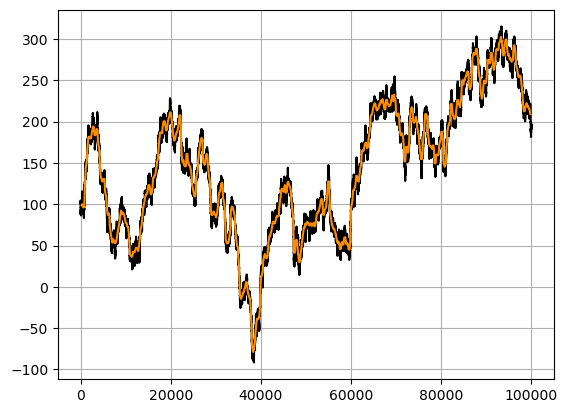

In [6]:
plt.plot(raw_signals[:subset_size], 'k-')
plt.plot(raw_signals_median_pure[:subset_size], '-', color='darkorange')
plt.grid()

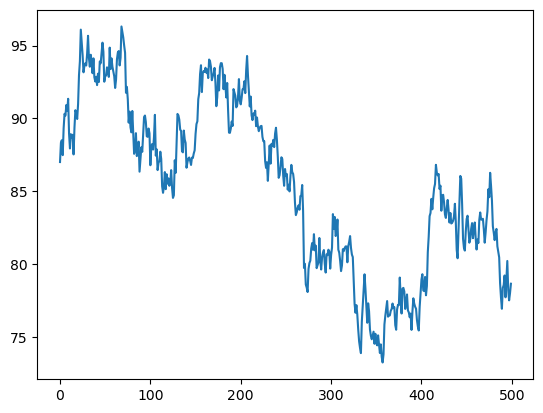

In [7]:
# plot one window that is used for median calculation
i=10000
data_window = raw_signals[i - window:i]
plt.plot(data_window)

(20000.0, 30000.0)

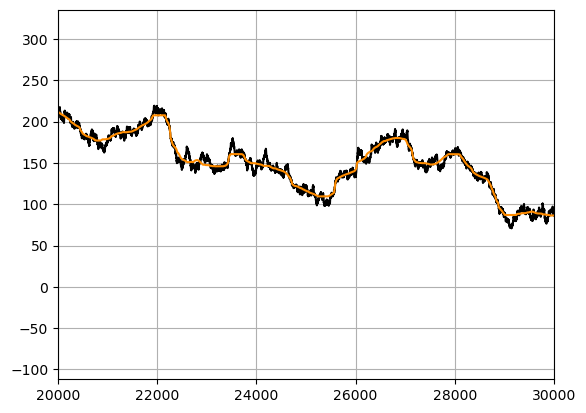

In [8]:
plt.plot(raw_signals[:subset_size], 'k-')
plt.plot(raw_signals_median_pure[:subset_size], '-', color='darkorange')
plt.grid()
plt.xlim([20000,30000])

## 3. Enter Numba (Single-Threaded JIT Compilation)

By simply adding the `@njit` decorator, Numba will compile this function on its first execution into highly optimized machine code.

### What is `njit`?
It stands for "No Python" JIT. It forces Numba to compile the function entirely without relying on the slow Python runtime library. If it encounters something it can't optimize, it will throw an error rather than silently falling back to slow Python mode.

In [9]:
@njit
def compute_rolling_median_numba(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    for i in range(window_size, n):
        window = data[i - int(window_size/2):i + int(window_size/2)]
        output[i] = np.median(window)
    return output

window = 500
print("Compilation + Execution Run (on the FULL 20 million dataset)...")
start = time.time()
numba_single_results = compute_rolling_median_numba(raw_signals, window)
numba_single_duration = time.time() - start

print(f"Numba Single-Threaded finished FULL dataset in: {numba_single_duration:.2f} seconds!")
print(f"Speedup over estimated pure Python: ~{estimated_full_time / numba_single_duration:.1f}x faster")

Compilation + Execution Run (on the FULL 20 million dataset)...
Numba Single-Threaded finished FULL dataset in: 52.62 seconds!
Speedup over estimated pure Python: ~4.2x faster


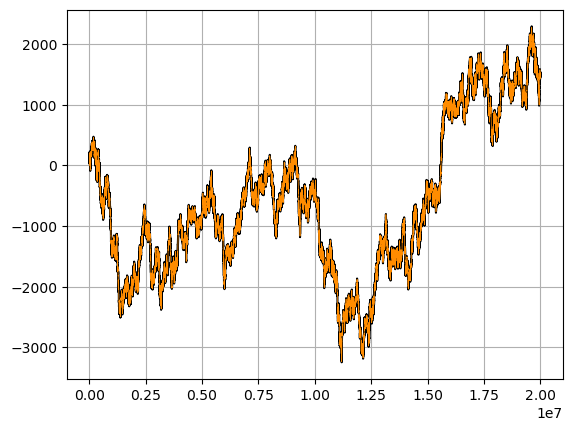

In [11]:
plt.plot(raw_signals, 'k-')
plt.plot(numba_single_results, '-', lw=0.5, color='darkorange')
plt.grid()

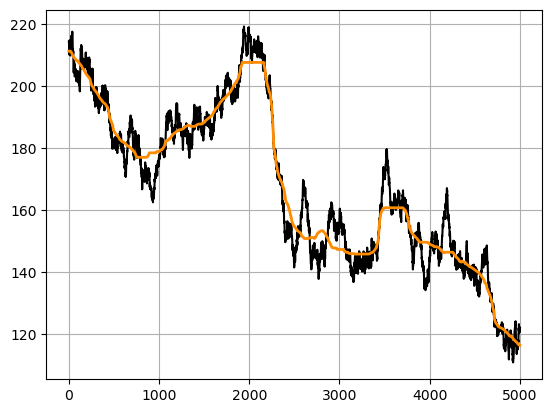

In [12]:
plt.plot(raw_signals[20000:25000], 'k-')
plt.plot(numba_single_results[20000:25000], '-', lw=2, color='darkorange')
plt.grid()

## 4. Unlocking Full CPU Potential: Numba Parallelization

While the compiled single-threaded code is incredibly fast, it's still running on just one CPU core.

To parallelize with Numba, we make two tiny changes:
1. Pass `parallel=True` into the `@njit` decorator.
2. Swap the outer `range` loop for `prange` (Parallel Range). This tells Numba's compiler that the iterations of this loop are independent of each other and can be safely executed across different CPU cores simultaneously.

In [10]:
@njit(parallel=True)
def compute_rolling_median_parallel(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    # prange automatically distributes loop indexes across available CPU threads
    for i in prange(window_size, n):
        window = data[i - int(window_size/2):i + int(window_size/2)]
        output[i] = np.median(window)
    return output

# First run includes compilation overhead
window=500
print("Compiling and running parallel implementation...")
start = time.time()
numba_parallel_results = compute_rolling_median_parallel(raw_signals, window)
numba_parallel_duration = time.time() - start

print(f"Numba Parallel finished FULL dataset in: {numba_parallel_duration:.2f} seconds!")

Compiling and running parallel implementation...
Numba Parallel finished FULL dataset in: 7.88 seconds!


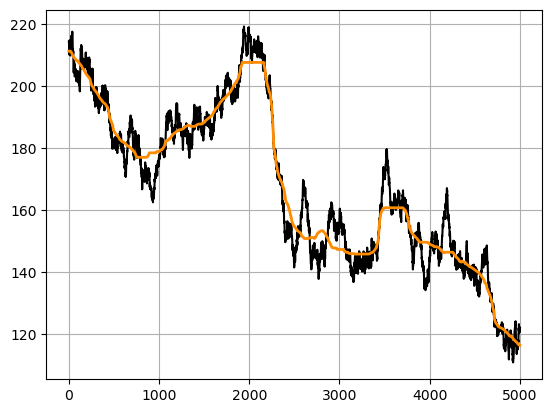

In [22]:
plt.plot(raw_signals[20000:25000], 'k-')
# plt.plot(numba_single_results[20000:25000], '-', lw=2, color='darkorange')
plt.plot(numba_parallel_results[20000:25000], '-', lw=2, color='darkorange')
plt.grid()

# Median vs. Mean Filter

We are going to compare a median with a mean filter approach using parallelized for loops.

A rolling (moving) mean calculates the average of values in a window, smoothing out data and heavily weighting extreme outliers. A rolling (moving) median finds the middle value in the sorted window, completely ignoring extreme outliers while preserving sharp changes and edges in the data.


Best ForWhite noise, continuous/normally distributed data, and general visual smoothing."Salt and pepper" noise, spike/glitch removal, and financial data.

**Use the Rolling Mean if:** Your data contains primarily Gaussian (normal) noise and you want to calculate a general trend or smoothly blend the signal. It is also computationally lighter for massive datasets.

**Use the Rolling Median if:** Your data contains sudden, abrupt spikes (like a malfunctioning sensor) or you want to track a trendline without letting rare, extreme events (like a sudden market crash or price spike) drag the average off-course

In [16]:
@njit(parallel=True)
def compute_rolling_median_parallel(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    # prange automatically distributes loop indexes across available CPU threads
    for i in prange(window_size, n):
        window = data[i - int(window_size/2):i + int(window_size/2)]
        output[i] = np.median(window)
    return output

# First run includes compilation overhead
window=500
print("Compiling and running parallel implementation...")
start = time.time()
numba_median_parallel_results = compute_rolling_median_parallel(raw_signals, window)
numba_median_parallel_duration = time.time() - start

print(f"Numba Parallel finished FULL dataset in: {numba_median_parallel_duration:.2f} seconds!")

Compiling and running parallel implementation...
Numba Parallel finished FULL dataset in: 7.51 seconds!


In [17]:
@njit(parallel=True)
def compute_rolling_mean_parallel(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    # prange automatically distributes loop indexes across available CPU threads
    for i in prange(window_size, n):
        window = data[i - int(window_size/2):i + int(window_size/2)]
        output[i] = np.mean(window)
    return output

# First run includes compilation overhead
window=500
print("Compiling and running parallel implementation...")
start = time.time()
numba_mean_parallel_results = compute_rolling_mean_parallel(raw_signals, window)
numba_mean_parallel_duration = time.time() - start

print(f"Numba Parallel finished FULL dataset in: {numba_mean_parallel_duration:.2f} seconds!")

Compiling and running parallel implementation...
Numba Parallel finished FULL dataset in: 0.88 seconds!


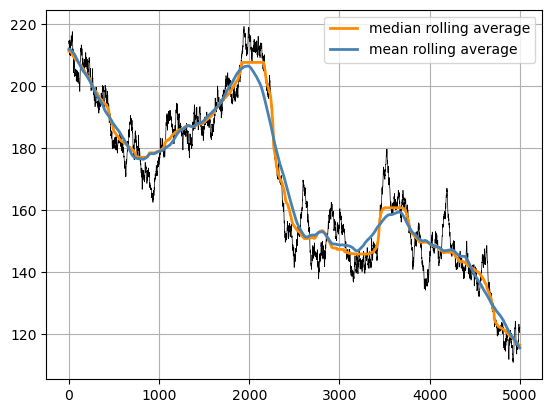

In [18]:
plt.plot(raw_signals[20000:25000], 'k-', lw=0.5)
plt.plot(numba_median_parallel_results[20000:25000], '-', lw=2, color='darkorange', label='median rolling average')
plt.plot(numba_mean_parallel_results[20000:25000], '-', lw=2, color='steelblue', label='mean rolling average')
plt.grid()
plt.legend()

## Task

Repeat with changing window sizes!

## Crucial Rules for Numba Parallelization

1. **First-Run Compilation Overhead:** The very first time you invoke a Numba function, it compiles it. This takes an extra 0.5 to 2 seconds. Subsequent runs will be pure machine-speed.
2. **Race Conditions:** Only use `prange` if the loop operations are independent. If iteration `i` needs data calculated in iteration `i-1`, parallel loops will produce scrambled data.
3. **No Arbitrary Python Objects:** Numba cannot handle complex Python entities like custom dictionary structures or specialized Pandas DataFrames inside an `@njit` block. Keep inputs restricted to **NumPy arrays** and scalars.

# Optional example: Advanced example using trigonometric functions

In actual time-series analysis (such as financial quantitative trading, radar signal processing, or seismic analysis), you rarely just calculate a simple rolling average. Simple averages smooth out data but destroy information about local frequencies, cycles, and volatility.

Multiplying trigonometric functions like sine and cosine inside a sliding window simulates analyzing signal phases, wave interference, or cyclic variations.

**Example** Earth Data Scaling: Combining sin(x) * cos(x) bounds the values strictly between -0.5 and 0.5 (due to the double-angle trig identity: $\sin(x)\cos(x) = \frac{1}{2}\sin(2x)$). This acts as a rolling non-linear filter that scales down extreme anomalies while preserving cyclic patterns within that specific lookback window.

### How sin(x) * cos(x) Natively Dynamically Scales Volatility
By utilizing the trigonometric double-angle identity from mathematics:$$\sin(x)\cos(x) = \frac{1}{2}\sin(2x)$$We unlock a fascinating structural constraint perfectly suited for time-series scaling:

**Strict Hard Boundaries:** No matter how massive the input number $x$ becomes—whether it is $1.5$ or $9,999,999.0$—the output of $\sin(x)\cos(x)$ is mathematically guaranteed to stay strictly between $-0.5$ and $+0.5$.

**Anomaly Dampening:** If a sensor suffers a sudden outlier spike (e.g., jumping from a normal reading of $50$ to an error reading of $50,000$), a standard linear model breaks. But a cyclic model wraps that number back into the $-0.5$ to $+0.5$ domain. It prevents a single outlier from distorting the downstream calculation.

**Amplifying Micro-Movements in Calm Periods:** When a signal is quiet and hovering within small ranges, the slope of trigonometric functions near zero is relatively steep. This means small, subtle changes in a quiet environment are amplified, while massive, violent swings in a volatile environment are compressed into the same wave boundaries.

In time-series analysis and signal processing, combining trigonometric bounded operations with an exponential function serves a vital mathematical purpose known as Log-Linear Mapping or Geometric Standardization.

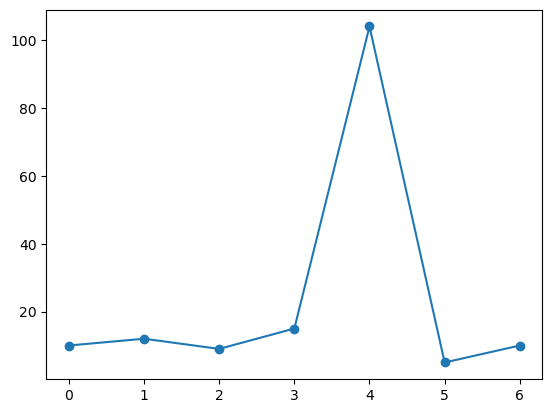

In [15]:
ts = np.array([10, 12, 9, 15, 104, 5, 10])
plt.plot(ts, 'o-')

In [16]:
np.mean(ts)

23.571428571428573

*Is there a different way of averaging?*

In [30]:
np.sin(10) * np.cos(10)

0.4564726253638138

In [17]:
np.sin(104) * np.cos(104)

0.30453396509553016

In [18]:
len(ts)

7

In [19]:
# Simulating a complex math calculation inside the window
window_size = len(ts)
acc = 0.0
for j in range(window_size):
    acc += np.sin(ts[j]) * np.cos(ts[j])
output = np.exp(acc / window_size)
output

0.9475904821943972

In [20]:
np.exp(np.sum(np.sin(ts)*np.cos(ts)) / window_size)

0.9475904821943972

In [ ]:
# The mean is 

**Why scaling with an exponential**

In [35]:
10/window_size

1.1111111111111112

In [36]:
100/window_size

11.11111111111111

In [37]:
np.exp(10/window_size)

3.037731777517483

## A Native Python / NumPy Baseline Approach

Let's look at how a naive implementation handles this sliding window problem. We will intentionally keep the loop explicit to showcase the performance barrier.

*Note: To prevent your notebook from freezing, we will only run this baseline on a **tiny fraction** (0.5%) of our dataset.*

In [21]:
def compute_rolling_metric_pure(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    # Explicit loop mimicking standard time-series analysis logic
    for i in range(window_size, n):
        window = data[i - window_size:i]
        
        # Simulating a complex math calculation inside the window
        acc = 0.0
        for j in range(window_size):
            acc += np.sin(window[j]) * np.cos(window[j])
        
        output[i] = np.exp(acc / window_size)
        # output[i] = np.exp(np.sum(np.sin(ts)*np.cos(ts)) / window_size)
    return output

# Run on a subset (100,000 items) just to get a baseline time
subset_size = 100_000
window = 500

print(f"Running Pure Python loop on a SUBSET of {subset_size:,} elements...")
start = time.time()
raw_signals_pure_smoothed = compute_rolling_metric_pure(raw_signals[:subset_size], window)
pure_duration = time.time() - start

# Estimate how long the FULL dataset would take
estimated_full_time = pure_duration * (n_samples / subset_size)
print(f"Subset finished in: {pure_duration:.2f} seconds.")
print(f"Estimated time for the full 20M dataset in Pure Python: {estimated_full_time:.2f} seconds (~{estimated_full_time/60:.1f} minutes!)")

Running Pure Python loop on a SUBSET of 100,000 elements...
Subset finished in: 47.75 seconds.
Estimated time for the full 20M dataset in Pure Python: 9549.92 seconds (~159.2 minutes!)


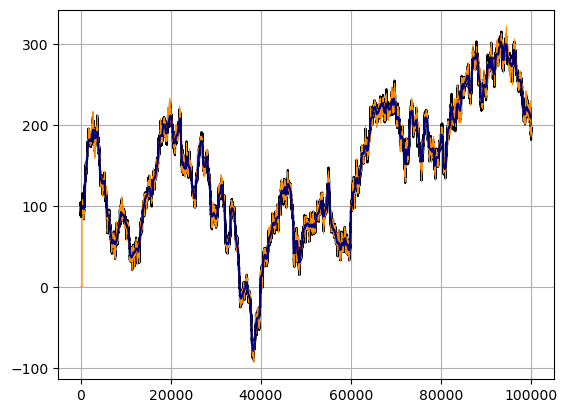

In [56]:
plt.plot(raw_signals[:subset_size], 'k-')
plt.plot(raw_signals_pure_smoothed * raw_signals[:subset_size], '-', lw=0.5, color='darkorange')
plt.plot(raw_signals_median_pure, '-', color='navy')
plt.grid()

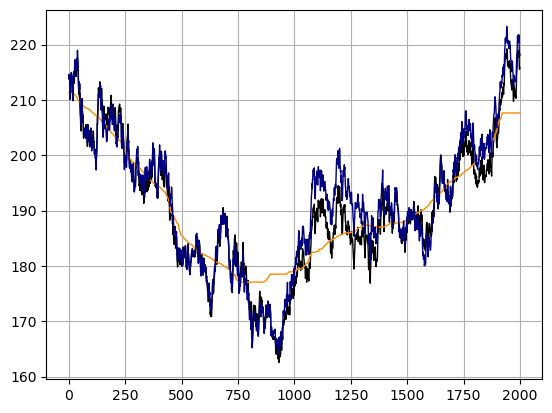

In [22]:
plt.plot(raw_signals[:subset_size][20000:22000], 'k-', lw=1)
plt.plot(raw_signals_median_pure[20000:22000], '-', lw=1, color='darkorange')
plt.plot(raw_signals_pure_smoothed[20000:22000] * raw_signals[:subset_size][20000:22000], '-', lw=1, color='navy')
plt.grid()

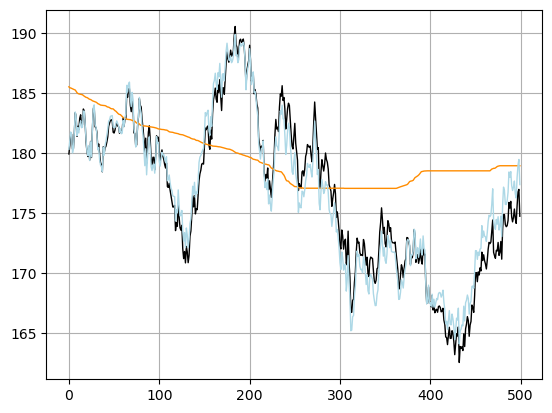

In [23]:
plt.plot(raw_signals[:subset_size][20500:21000], 'k-', lw=1)
plt.plot(raw_signals_median_pure[20500:21000], '-', lw=1, color='darkorange')
plt.plot(raw_signals_pure_smoothed[20500:21000] * raw_signals[:subset_size][20500:21000], '-', lw=1, color='lightblue')
plt.grid()

## A Numba-based approach (Single-Threaded JIT Compilation)

By simply adding the `@njit` decorator, Numba will compile this function on its first execution into highly optimized machine code.

### What is `njit`?
It stands for "No Python" JIT. It forces Numba to compile the function entirely without relying on the slow Python runtime library. If it encounters something it can't optimize, it will throw an error rather than silently falling back to slow Python mode.

In [60]:
@njit
def compute_rolling_metric_numba(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    for i in range(window_size, n):
        window = data[i - window_size:i]
        acc = 0.0
        for j in range(window_size):
            acc += np.sin(window[j]) * np.cos(window[j])
        output[i] = np.exp(acc / window_size) * data[i]
        # output[i] = np.exp(np.sum(np.sin(ts)*np.cos(ts)) / window_size)
    return output

print("Compilation + Execution Run (on the FULL 20 million dataset)...")
start = time.time()
numba_single_results = compute_rolling_metric_numba(raw_signals, window)
numba_single_duration = time.time() - start

print(f"Numba Single-Threaded finished FULL dataset in: {numba_single_duration:.2f} seconds!")
print(f"Speedup over estimated pure Python: ~{estimated_full_time / numba_single_duration:.1f}x faster")

Compilation + Execution Run (on the FULL 20 million dataset)...
Numba Single-Threaded finished FULL dataset in: 99.40 seconds!
Speedup over estimated pure Python: ~93.5x faster


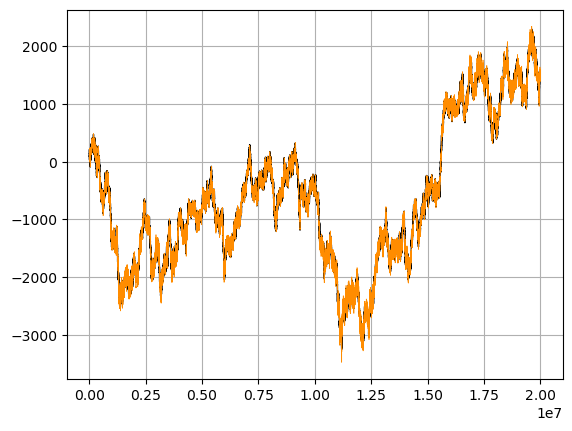

In [62]:
plt.plot(raw_signals, 'k-', lw=1)
plt.plowindow = 500
plt.plot(numba_single_results, '-', lw=0.5, color='darkorange')
plt.grid()

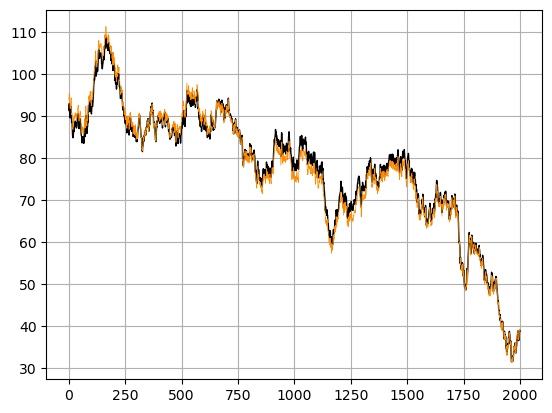

In [63]:
plt.plot(raw_signals[9000:11000], 'k-', lw=1)
plt.plot(numba_single_results[9000:11000], '-', lw=0.5, color='darkorange')
plt.grid()

## Unlocking Full CPU Potential: Numba Parallelization

While the compiled single-threaded code is incredibly fast, it's still running on just one CPU core.

To parallelize with Numba, we make two tiny changes:
1. Pass `parallel=True` into the `@njit` decorator.
2. Swap the outer `range` loop for `prange` (Parallel Range). This tells Numba's compiler that the iterations of this loop are independent of each other and can be safely executed across different CPU cores simultaneously.

In [64]:
@njit(parallel=True)
def compute_rolling_metric_parallel(data, window_size):
    n = len(data)
    output = np.zeros(n)
    
    # prange automatically distributes loop indexes across available CPU threads
    for i in prange(window_size, n):
        window = data[i - window_size:i]
        acc = 0.0
        for j in range(window_size):
            acc += np.sin(window[j]) * np.cos(window[j])
        output[i] = np.exp(acc / window_size)
        # output[i] = np.exp(np.sum(np.sin(ts)*np.cos(ts)) / window_size)
    return output

# First run includes compilation overhead
window=500
print("Compiling and running parallel implementation...")
start = time.time()
numba_parallel_results = compute_rolling_metric_parallel(raw_signals, window)
numba_parallel_duration = time.time() - start

print(f"Numba Parallel finished FULL dataset in: {numba_parallel_duration:.2f} seconds!")

Compiling and running parallel implementation...
Numba Parallel finished FULL dataset in: 19.38 seconds!


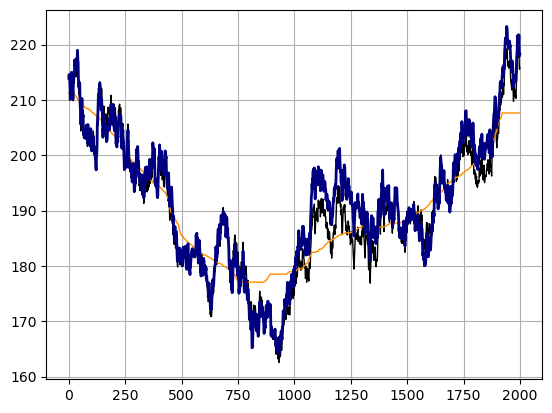

In [70]:
plt.plot(raw_signals[20000:22000], 'k-', lw=1)
plt.plot(raw_signals_median_pure[20000:22000], '-', lw=1, color='darkorange')
plt.plot(numba_parallel_results[20000:22000]*raw_signals[20000:22000], '-', lw=2, color='navy')
plt.grid()


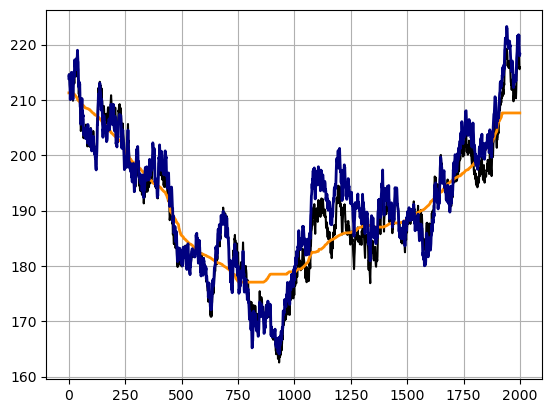

In [75]:
plt.plot(raw_signals[20000:22000], 'k-')
plt.plot(raw_signals_median_pure[20000:22000], '-', lw=2, color='darkorange')
plt.plot(numba_parallel_results[20000:22000]*raw_signals[20000:22000], '-', lw=2, color='navy')
plt.grid()

## Crucial Rules for Numba Parallelization

1. **First-Run Compilation Overhead:** The very first time you invoke a Numba function, it compiles it. This takes an extra 0.5 to 2 seconds. Subsequent runs will be pure machine-speed.
2. **Race Conditions:** Only use `prange` if the loop operations are independent. If iteration `i` needs data calculated in iteration `i-1`, parallel loops will produce scrambled data.
3. **No Arbitrary Python Objects:** Numba cannot handle complex Python entities like custom dictionary structures or specialized Pandas DataFrames inside an `@njit` block. Keep inputs restricted to **NumPy arrays** and scalars.